# Zomato Delivery Operations Analytics

## Project Objective
Zomato's operations team wants to understand what factors most impact 
delivery time and customer satisfaction across Indian cities. As a Data 
Analyst, the goal is to identify the biggest operational gaps and provide 
a prioritized, data-driven action plan for the operations team.

## Business Questions We Are Solving
1. Which city type has the worst delivery performance?
2. Does delivery person age or ratings affect delivery time?
3. Do weather and road traffic significantly increase delivery time — and by how much?
4. Which order types and vehicle types are associated with the most delays?
5. What is the single biggest lever the ops team should pull to reduce delivery time?

## Tools & Technologies
- Python 3.11
- Pandas — Data manipulation and analysis
- NumPy — Numerical computations
- Matplotlib — Data visualization
- Seaborn — Statistical data visualization
- SQLite3 — SQL-based analysis on structured data

## Dataset
- Source: Kaggle — Zomato Delivery Operations Analytics Dataset
- Size: 45,584 rows × 20 columns
- Each row represents one food delivery transaction

## Project Structure
- Phase 1 — Data Ingestion & Initial Inspection
- Phase 2 — Data Cleaning & Preprocessing
- Phase 3 — Exploratory Data Analysis (EDA)
- Phase 4 — Core Business Analysis
- Phase 5 — Data Visualization
- Phase 6 — SQL Analysis
- Phase 7 — Insights & Business Recommendations

## Phase 1 — Data Ingestion & Initial Inspection

**What is Data Ingestion?**
Data Ingestion is the process of loading raw data from its source into 
our working environment for analysis. This is always the first technical 
step in any data analytics project.

**What is Initial Inspection?**
Before doing anything with data, a professional analyst always performs 
an initial inspection — understanding the shape of the data, what each 
column represents, what data types are present, and whether there are 
any immediate red flags like missing values or incorrect formats.

**Why this matters:**
You cannot clean what you don't understand. You cannot analyse what you 
haven't inspected. This phase gives us the full picture of what we're 
working with before we touch a single value.

In [1]:
#---------------------------------------------------------------
# PHASE 1 — DATA INGESTION & INITIAL INSPECTION
#---------------------------------------------------------------
# Step 1: Import necessary libraries
import pandas as pd    # For data manipulation and analysis
import numpy as np     # For numerical operations 
import matplotlib.pyplot as plt   # Visualization 
import seaborn as sns  # Statistical Visualization 
import warnings
warnings.filterwarnings('ignore')

# Setting display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [2]:
# Step 1 -  Loading the dataset ──
df = pd.read_csv('/Users/mirajpatil/Documents/Zomato-Delivery-Analytics/Data/Zomato Dataset.csv')
print("✅ Dataset loaded successfully")

✅ Dataset loaded successfully


In [3]:
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Shape: 45584 rows × 20 columns


In [4]:
# Step 2 -  Now lets do the data inspection by looking at the first few rows from Top and in next cell from bottom as well 
print('First 10 rows:')
print(df.head(10))

First 10 rows:
       ID Delivery_person_ID  Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  Delivery_location_longitude  Order_Date Time_Orderd Time_Order_picked Weather_conditions Road_traffic_density  Vehicle_condition Type_of_order   Type_of_vehicle  multiple_deliveries Festival           City  Time_taken (min)
0  0xcdcd      DEHRES17DEL01                 36.0                      4.2            30.327968             78.046106                   30.397968                    78.116106  12-02-2022       21:55             22:10                Fog                  Jam                  2         Snack        motorcycle                  3.0       No  Metropolitian                46
1  0xd987      KOCRES16DEL01                 21.0                      4.7            10.003064             76.307589                   10.043064                    76.347589  13-02-2022       14:55             15:05             Stormy        

In [5]:
print('Last 10 rows:')
print(df.tail(10))

Last 10 rows:
           ID Delivery_person_ID  Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  Delivery_location_longitude  Order_Date Time_Orderd Time_Order_picked Weather_conditions Road_traffic_density  Vehicle_condition Type_of_order   Type_of_vehicle  multiple_deliveries Festival           City  Time_taken (min)
45574  0x5193      MYSRES13DEL02                 36.0                      4.8            12.310972             76.659264                   12.440972                    76.789264  18-03-2022       21:10             21:20              Sunny                  Jam                  2        Drinks  electric_scooter                  1.0       No          Urban                29
45575  0xa333     CHENRES08DEL02                 37.0                      4.8            13.022394             80.242439                   13.042394                    80.262439  05-04-2022       09:35             09:50         Sandsto

In [6]:
# step 3 - Understanding data types and structure of data frame 
print('Data info:')
print(df.info()) # info gives the overview or our data such as - all columns, non-null-values, data type

Data info:
<class 'pandas.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  str    
 1   Delivery_person_ID           45584 non-null  str    
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  str    
 9   Time_Orderd                  43853 non-null  str    
 10  Time_Order_picked            45584 non-null  str    
 11  Weather_conditions           44968 non-null  str    
 12  Road_traffic_density         44983 non-null  str    
 13  Vehicle_conditio

In [7]:
# step 4 - Statistical summary of numerical values 
print('statistical summary:')
print(df.describe()) # describe gives statistical summary of numerical values 

statistical summary:
       Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  Delivery_location_longitude  Vehicle_condition  multiple_deliveries  Time_taken (min)
count         43730.000000             43676.000000         45584.000000          45584.000000                45584.000000                 45584.000000       45584.000000         44591.000000      45584.000000
mean             29.566911                 4.633774            17.017948             70.229684                   17.465480                    70.844161           1.023385             0.744635         26.293963
std               5.815064                 0.334744             8.185674             22.885575                    7.335562                    21.120578           0.839055             0.572510          9.384298
min              15.000000                 1.000000           -30.905562            -88.366217                    0.010000                 

In [8]:
# step 5 - checking Unique values in categorical column

categorical_cols = ['Weather_conditions','Road_traffic_density','Type_of_order','Type_of_vehicle','Festival','City']

for col in categorical_cols: # so we use for loop to iterate through each column of categorical data and find unique value and its count
    print(f'\n{col}: {df[col].nunique()} unique values')
    print(df[col].value_counts())




Weather_conditions: 6 unique values
Weather_conditions
Fog           7653
Stormy        7584
Cloudy        7533
Sandstorms    7494
Windy         7422
Sunny         7282
Name: count, dtype: int64

Road_traffic_density: 4 unique values
Road_traffic_density
Low       15476
Jam       14139
Medium    10945
High       4423
Name: count, dtype: int64

Type_of_order: 4 unique values
Type_of_order
Snack     11530
Meal      11456
Drinks    11321
Buffet    11277
Name: count, dtype: int64

Type_of_vehicle: 4 unique values
Type_of_vehicle
motorcycle          26429
scooter             15273
electric_scooter     3814
bicycle                68
Name: count, dtype: int64

Festival: 2 unique values
Festival
No     44460
Yes      896
Name: count, dtype: int64

City: 3 unique values
City
Metropolitian    34087
Urban            10133
Semi-Urban         164
Name: count, dtype: int64


## Phase 1 — Summary of Initial Inspection Findings

| Finding | Column | Action Required |
|---|---|---|
| Ages below 18 found | Delivery_person_Age | Remove rows where age < 18 |
| Rating value of 6.0 found | Delivery_person_Ratings | Cap ratings at 5.0 |
| Negative coordinates found | Lat/Long columns | Drop coordinate columns entirely |
| Misspelled city name | City | Rename Metropolitian → Metropolitan |
| Semi-Urban has only 164 rows | City | Drop Semi-Urban rows |
| Bicycle has only 68 rows | Type_of_vehicle | Drop Bicycle rows |
| Time_Orderd has 1731 nulls | Time_Orderd | Drop column — not needed |
| Multiple columns have nulls | Age, Ratings, Weather, Traffic, Festival, City | Handle in cleaning phase |

**Target Variable Status:** Time_taken (min) — 45,584 non-null — Clean ✅

## Phase 2 — Data Cleaning & Preprocessing

### What is Data Cleaning?
Data Cleaning is the process of identifying and correcting errors, 
inconsistencies, and inaccuracies in raw data before analysis. 
Real-world data is never perfect — it contains missing values, 
outliers, incorrect data types, and formatting issues that must 
be resolved before any meaningful analysis can be performed.

### What is Data Preprocessing?
Data Preprocessing goes one step further — it transforms cleaned 
data into a format that is optimized for analysis. This includes 
fixing data types, standardizing category names, creating new 
columns, and removing columns that add no analytical value.

### Why this phase is critical:
Garbage in, garbage out. If we analyse dirty data, our insights 
will be wrong. Every business decision made from bad data costs 
companies money. A professional analyst never skips this phase.

### What we will fix in this phase:
1. Drop unnecessary columns
2. Fix data types
3. Handle missing values
4. Fix outliers in Age and Ratings
5. Fix City name typo
6. Remove Semi-Urban and Bicycle rows
7. Rename columns for cleaner access

In [9]:
#-------------------------------------------------
# PHASE 2 - DATA CLEANING AND PREPROCESSING 
#-------------------------------------------------


# --- Step 1 - Drop unnecessary columns  ---
# we will drop columns that have no analytical value for what question we are solving 
# all coordinate columns - because we are not doing geographic or map analysis 
# ID and Delivery_person_ID — unique identifiers, no analytical value
# # Time_Ordered — 1,731 missing values and not needed for our analysis


columns_to_drop = [
    'ID',
    'Delivery_person_ID', 
    'Restaurant_latitude',
    'Restaurant_longitude',
    'Delivery_location_latitude',
    'Delivery_location_longitude',
    'Time_Orderd'
]

df.drop(columns=columns_to_drop, inplace=True)

print("✅ Unnecessary columns dropped")
print(f"New shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Remaining columns: {list(df.columns)}")

✅ Unnecessary columns dropped
New shape: 45584 rows × 13 columns
Remaining columns: ['Delivery_person_Age', 'Delivery_person_Ratings', 'Order_Date', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)']


In [10]:
# --- Step 2 - Fix Data Type of Date Column -----
# order data is stored as string so we will change it to datetime for time based analysis 
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%M-%Y')

In [11]:
df.info() # now it is change to datetime format 

<class 'pandas.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Delivery_person_Age      43730 non-null  float64       
 1   Delivery_person_Ratings  43676 non-null  float64       
 2   Order_Date               45584 non-null  datetime64[us]
 3   Time_Order_picked        45584 non-null  str           
 4   Weather_conditions       44968 non-null  str           
 5   Road_traffic_density     44983 non-null  str           
 6   Vehicle_condition        45584 non-null  int64         
 7   Type_of_order            45584 non-null  str           
 8   Type_of_vehicle          45584 non-null  str           
 9   multiple_deliveries      44591 non-null  float64       
 10  Festival                 45356 non-null  str           
 11  City                     44384 non-null  str           
 12  Time_taken (min)         45584 non-null  in

In [12]:
# Lets Extract Month and Day of week for trend analysis which we will do later 
df['order_month'] = df['Order_Date'].dt.month_name()
df['order_dayofweek'] = df['Order_Date'].dt.day_name()

In [13]:
print(f"Order_Date dtype: {df['Order_Date'].dtype}")
print(f"\nMonths present: {df['order_month'].unique()}")
print(f"\nDays present: {df['order_dayofweek'].unique()}")

Order_Date dtype: datetime64[us]

Months present: <StringArray>
['January']
Length: 1, dtype: str

Days present: <StringArray>
['Wednesday', 'Thursday', 'Tuesday', 'Friday', 'Sunday', 'Saturday', 'Monday']
Length: 7, dtype: str


In [14]:
#-- Step - 3 - Handle Missing Values ------- This is a main part because it directly impact the accuracy of our analysis 
print("Missing Values Before cleaning:")
print(df.isnull().sum()) # it will give the sum of all na values in each column so we will handle one by one and we also get the idea
# of which column has na values and which column do not have na 

Missing Values Before cleaning:
Delivery_person_Age        1854
Delivery_person_Ratings    1908
Order_Date                    0
Time_Order_picked             0
Weather_conditions          616
Road_traffic_density        601
Vehicle_condition             0
Type_of_order                 0
Type_of_vehicle               0
multiple_deliveries         993
Festival                    228
City                       1200
Time_taken (min)              0
order_month                   0
order_dayofweek               0
dtype: int64


In [15]:
# Delivery_person_Age — fill with median (robust to outliers) - because as we already checked describe and understood that it has a balanced data 
# and spread is not skewed a lot so we can use median also median is more accurate and mean is sensitive to outlier 
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median())

# Delivery_person_Ratings — fill with median
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median())

# Weather_Condition - so for this to fill we will use Mode because it gives most frequent value also this is categorical data 
df['Weather_conditions'] = df['Weather_conditions'].fillna(df['Weather_conditions'].mode()[0])

# Road_Traffic_density - to fill na here we will use mode because this is also categorical data 
df['Road_traffic_density'] = df['Road_traffic_density'].fillna(df['Road_traffic_density'].mode()[0])

# multiple_deliveries - will fill with Median 
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(df['multiple_deliveries'].median())

# Festival - will fill with mode 
df['Festival'] = df['Festival'].fillna(df['Festival'].mode()[0])

# city - drop rows when city is null because we can not guess city for this many data and can not replace it also 
df = df.dropna(subset=['City'])

print("\n✅ Missing values handled")
print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())
print(f"\nShape after handling missing values: {df.shape}")


✅ Missing values handled

Missing values AFTER cleaning:
Delivery_person_Age        0
Delivery_person_Ratings    0
Order_Date                 0
Time_Order_picked          0
Weather_conditions         0
Road_traffic_density       0
Vehicle_condition          0
Type_of_order              0
Type_of_vehicle            0
multiple_deliveries        0
Festival                   0
City                       0
Time_taken (min)           0
order_month                0
order_dayofweek            0
dtype: int64

Shape after handling missing values: (44384, 15)


In [16]:
#---- Step - 4: Fix Outliers -------------

# Remove delivery persons below 18 — legal minimum working age in India
before = df.shape[0]
df = df[df['Delivery_person_Age'] >= 18]
after = df.shape[0]
print(f'removed {before - after} rows with age below 18')

removed 38 rows with age below 18


In [17]:
# Cap rating at 5.0 - zomato rating system is max at 5.0 
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].clip(upper=5.0) # we use clip to set a boundary so it converted 6.0 to 5.0
print(f"Max rating now: {df['Delivery_person_Ratings'].max()}")

Max rating now: 5.0


In [18]:
# Remove Semi-Urban rows — only 164 rows, statistically insignificant
before = df.shape[0]
df = df[df['City'] != 'Semi-Urban']
after = df.shape[0]
print(f'removed {before - after} rows from city which are Semi-Urban')

removed 164 rows from city which are Semi-Urban


In [19]:
# Remove Bicycle rows — only 68 rows, statistically insignificant
before = df.shape[0]
df = df[df['Type_of_vehicle'] != 'bicycle']
after = df.shape[0]
print(f'removed {before - after} rows form vehicle type which has in it  Bicycle')

removed 55 rows form vehicle type which has in it  Bicycle


In [20]:
print(f"\nShape after outlier treatment: {df.shape}")


Shape after outlier treatment: (44127, 15)


In [21]:
# ── Step 5: Fix City typo and standardize categorical values ──

# Fix Misspelled city name 
df['City'] = df['City'].replace('Metropolitian','Metropolitan')
df.City

0        Metropolitan
1        Metropolitan
2        Metropolitan
3        Metropolitan
4        Metropolitan
             ...     
45579    Metropolitan
45580    Metropolitan
45581    Metropolitan
45582    Metropolitan
45583    Metropolitan
Name: City, Length: 44127, dtype: str

In [22]:
# Fix data types — Age and multiple_deliveries should be integer

df['Delivery_person_Age'] = df['Delivery_person_Age'].astype(dtype=int)
df['multiple_deliveries'] = df['multiple_deliveries'].astype(dtype=int)

print(df[['Delivery_person_Age', 'multiple_deliveries']].dtypes)

Delivery_person_Age    int64
multiple_deliveries    int64
dtype: object


In [23]:
# Rename Time_taken (min) for easier access — spaces and brackets cause issues

df['Time_taken_min'] = df['Time_taken (min)']
df.drop(columns=['Time_taken (min)'], inplace=True)

In [24]:
# Verify City values
print("✅ City values after fix:")
print(df['City'].value_counts())

print(f"\n✅ Data types after fix:")
print(df[['Delivery_person_Age', 'multiple_deliveries', 'Time_taken_min']].dtypes)

print(f"\n✅ Final cleaned dataset shape: {df.shape}")

✅ City values after fix:
City
Metropolitan    34018
Urban           10109
Name: count, dtype: int64

✅ Data types after fix:
Delivery_person_Age    int64
multiple_deliveries    int64
Time_taken_min         int64
dtype: object

✅ Final cleaned dataset shape: (44127, 15)


In [25]:
# Quick sanity check on cleaned data
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nSample data:")
print(df.head(3))

Shape: (44127, 15)

Columns: ['Delivery_person_Age', 'Delivery_person_Ratings', 'Order_Date', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'order_month', 'order_dayofweek', 'Time_taken_min']

Data types:
Delivery_person_Age                 int64
Delivery_person_Ratings           float64
Order_Date                 datetime64[us]
Time_Order_picked                     str
Weather_conditions                    str
Road_traffic_density                  str
Vehicle_condition                   int64
Type_of_order                         str
Type_of_vehicle                       str
multiple_deliveries                 int64
Festival                              str
City                                  str
order_month                           str
order_dayofweek                       str
Time_taken_min                      int64
dtype: object

Missing values:
Delivery_pers

In [26]:
# Categorical columns final state
for col in ['Weather_conditions', 'Road_traffic_density', 
            'Type_of_order', 'Type_of_vehicle', 
            'Festival', 'City']:
    print(f"\n{col}:")
    print(df[col].value_counts())


Weather_conditions:
Weather_conditions
Fog           7949
Stormy        7366
Cloudy        7314
Sandstorms    7263
Windy         7196
Sunny         7039
Name: count, dtype: int64

Road_traffic_density:
Road_traffic_density
Low       15430
Jam       13713
Medium    10676
High       4308
Name: count, dtype: int64

Type_of_order:
Type_of_order
Meal      11120
Snack     11117
Drinks    10981
Buffet    10909
Name: count, dtype: int64

Type_of_vehicle:
Type_of_vehicle
motorcycle          25644
scooter             14783
electric_scooter     3700
Name: count, dtype: int64

Festival:
Festival
No     43288
Yes      839
Name: count, dtype: int64

City:
City
Metropolitan    34018
Urban           10109
Name: count, dtype: int64


In [27]:
df['Order_Date'] = df['Order_Date'].dt.date


## Phase 3 — Exploratory Data Analysis (EDA)

### What is EDA?
Exploratory Data Analysis is the process of analysing and visualising 
data to discover patterns, spot anomalies, test hypotheses, and check 
assumptions before formal analysis. It is the most creative and 
investigative phase of any data project.

### Types of analysis we perform in EDA:

**Univariate Analysis** — analysing one variable at a time
- What does the distribution of delivery time look like?
- Are ratings normally distributed?
- Which weather condition occurs most frequently?

**Bivariate Analysis** — analysing two variables together
- How does delivery time change with traffic density?
- Does weather condition affect delivery time?

### Why EDA matters:
EDA is where the data starts telling its story. Before building any 
formal analysis, we explore the data freely to understand its 
behaviour, find unexpected patterns, and confirm our initial 
hypotheses about what might be driving delivery time.

### Our EDA will cover:
1. Distribution of our target variable — Time_taken_min
2. Distribution of Delivery_person_Age and Ratings
3. Delivery time across Weather conditions
4. Delivery time across Traffic density
5. Delivery time across City types
6. Delivery time across Vehicle types
7. Correlation analysis — numerical variables

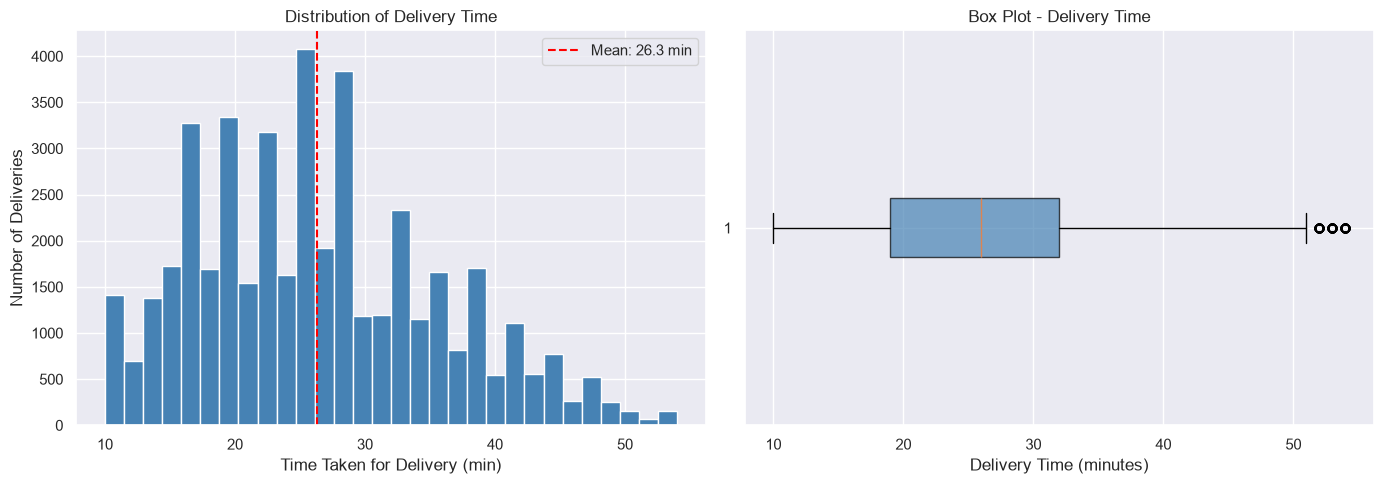

Mean Delivery Time: 26.32 minutes
Median Delivery Time: 26.00 minutes
Std Deviation: 9.29 minutes
Minimum Time 10 minutes | Maximum Time: 54 minutes


In [28]:
# ─────────────────────────────────────────────
# PHASE 3 — EXPLORATORY DATA ANALYSIS (EDA)
# ─────────────────────────────────────────────

# Set up visualization style

sns.set_theme(style='darkgrid') # seaborn already have theme preset just used it 
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['font.size'] = 12

# ── Step 1: Univariate Analysis — Target Variable ──
# Distribution of Delivery Time (our core metric)

fig, axes = plt.subplots(1,2, figsize=(14,5))

# HISTOGRAM 
axes[0].hist(df['Time_taken_min'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Delivery Time')
axes[0].set_xlabel('Time Taken for Delivery (min)')
axes[0].set_ylabel('Number of Deliveries')
axes[0].axvline(df['Time_taken_min'].mean(), color='Red',
                linestyle='--', label=f"Mean: {df['Time_taken_min'].mean():.1f} min")
axes[0].legend()


# Box Plot
axes[1].boxplot(df['Time_taken_min'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Box Plot - Delivery Time')
axes[1].set_xlabel('Delivery Time (minutes)')

plt.tight_layout()
plt.savefig('../visuals/01_delivery_time_distribution.png', dpi=150, bbox_inches='tight') 
plt.show()

print(f"Mean Delivery Time: {df['Time_taken_min'].mean():.2f} minutes")
print(f"Median Delivery Time: {df['Time_taken_min'].median():.2f} minutes")
print(f"Std Deviation: {df['Time_taken_min'].std():.2f} minutes")
print(f"Minimum Time {df['Time_taken_min'].min()} minutes | Maximum Time: {df['Time_taken_min'].max()} minutes")

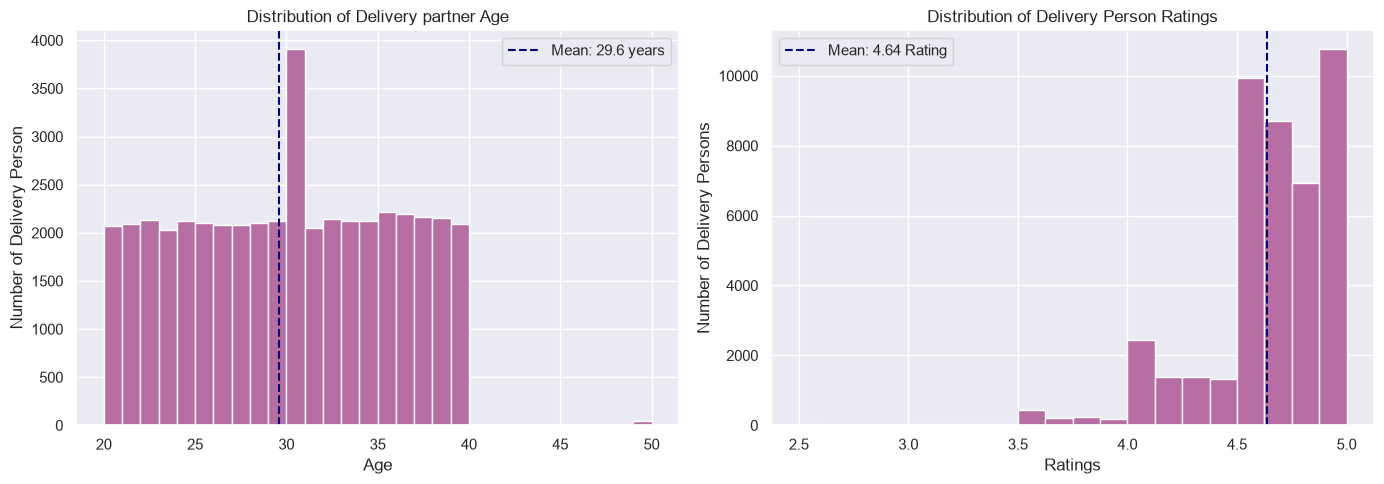

Mean Age of Delivery partners: 29.6 years | Minimum Age of Delivery partner: 20.0 years | Maximum Age of Delivery partner: 50.0 years
Mean Rating of partners: 4.64 | Minimum Rating of partner: 2.50 | Maximum Rating of partner: 5.00


In [29]:
# ── Step 2: Univariate Analysis — Delivery Person Age & Ratings ──

fig, axes = plt.subplots(1,2 , figsize=(14,5))

# Age Distribution 
axes[0].hist(df['Delivery_person_Age'], bins=30,
             color="#B76EA2", edgecolor='white')
axes[0].set_title('Distribution of Delivery partner Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Delivery Person')
axes[0].axvline(df['Delivery_person_Age'].mean(), color='navy',
                linestyle='--',
                label=f"Mean: {df['Delivery_person_Age'].mean():.1f} years")
axes[0].legend()

# Ratings Distribution
axes[1].hist(df['Delivery_person_Ratings'], bins=20,
             color="#B76EA2", edgecolor='white')
axes[1].set_title('Distribution of Delivery Person Ratings')
axes[1].set_xlabel('Ratings')
axes[1].set_ylabel('Number of Delivery Persons')
axes[1].axvline(df['Delivery_person_Ratings'].mean(),
                color='navy', linestyle='--',
                label=f"Mean: {df['Delivery_person_Ratings'].mean():.2f} Rating")
axes[1].legend()


plt.tight_layout()
plt.savefig('../visuals/02_age_ratings_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean Age of Delivery partners: {df['Delivery_person_Age'].mean():.1f} years | "
      f"Minimum Age of Delivery partner: {df['Delivery_person_Age'].min():.1f} years | "
      f"Maximum Age of Delivery partner: {df['Delivery_person_Age'].max():.1f} years")
print(f"Mean Rating of partners: {df['Delivery_person_Ratings'].mean():.2f} | "
      f"Minimum Rating of partner: {df['Delivery_person_Ratings'].min():.2f} | "
      f"Maximum Rating of partner: {df['Delivery_person_Ratings'].max():.2f}")

In [30]:
# ── Step 3: Bivariate Analysis — Weather vs Delivery Time ──

weather_avg = df.groupby('Weather_conditions')['Time_taken_min'].mean().sort_values(ascending=False).reset_index()
weather_avg

,Weather_conditions,Time_taken_min
0,Cloudy,28.887203
1,Fog,28.805384
2,Windy,26.151612
3,Stormy,25.917051
4,Sandstorms,25.909128
5,Sunny,21.869868


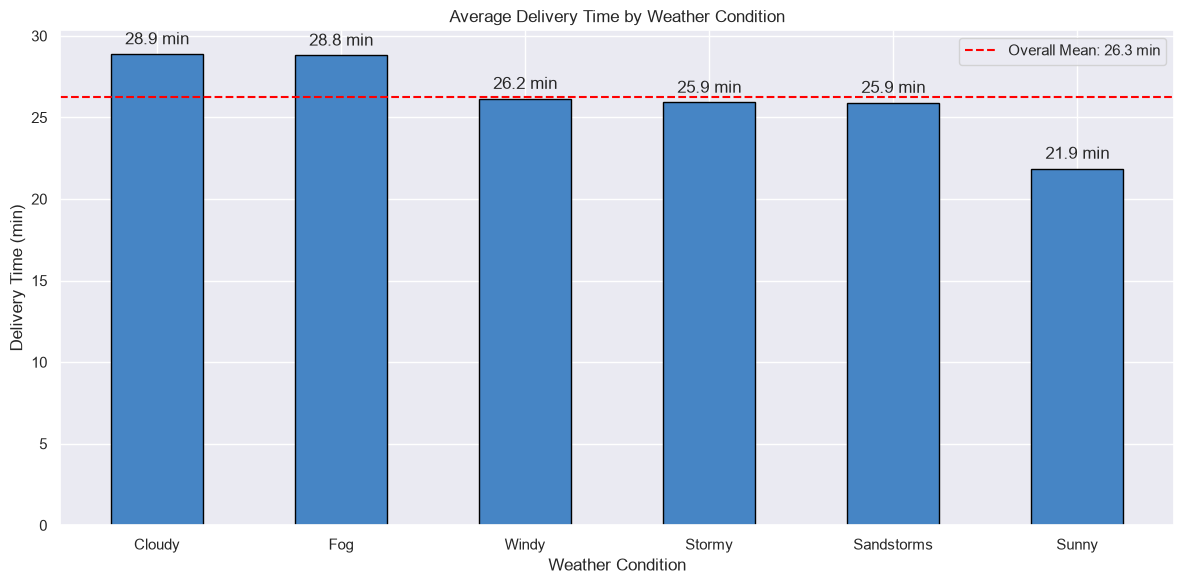

Average delivery time by weather condition:
Weather_conditions  Time_taken_min
            Cloudy       28.887203
               Fog       28.805384
             Windy       26.151612
            Stormy       25.917051
        Sandstorms       25.909128
             Sunny       21.869868


In [31]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(12,6))
bars = plt.bar(weather_avg['Weather_conditions'],
               weather_avg['Time_taken_min'],
               color="#4685C5", edgecolor='black', width=0.5)

# ADD value label om top of each bar
for bar, val in zip(bars, weather_avg['Time_taken_min']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.6,
             f"{val:.1f} min", ha='center', fontsize=12)
    
plt.axhline(weather_avg['Time_taken_min'].mean(),
            color='red', linestyle='--',
            label=f"Overall Mean: {df['Time_taken_min'].mean():.1f} min")
plt.legend()
plt.title('Average Delivery Time by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Delivery Time (min)')
plt.tight_layout()
plt.savefig('../visuals/03_weather_vs_delivery_time.png', dpi=150, bbox_inches='tight')
plt.show()


print("Average delivery time by weather condition:")
print(weather_avg.to_string(index=False))

In [32]:
# ── Step 4: Bivariate Analysis — Traffic Density vs Delivery Time ──

traffic_avg = df.groupby('Road_traffic_density')['Time_taken_min'].mean().sort_values(ascending=False).reset_index()
traffic_avg

,Road_traffic_density,Time_taken_min
0,Jam,31.111500
1,High,27.235376
2,Medium,26.754964
3,Low,21.508036


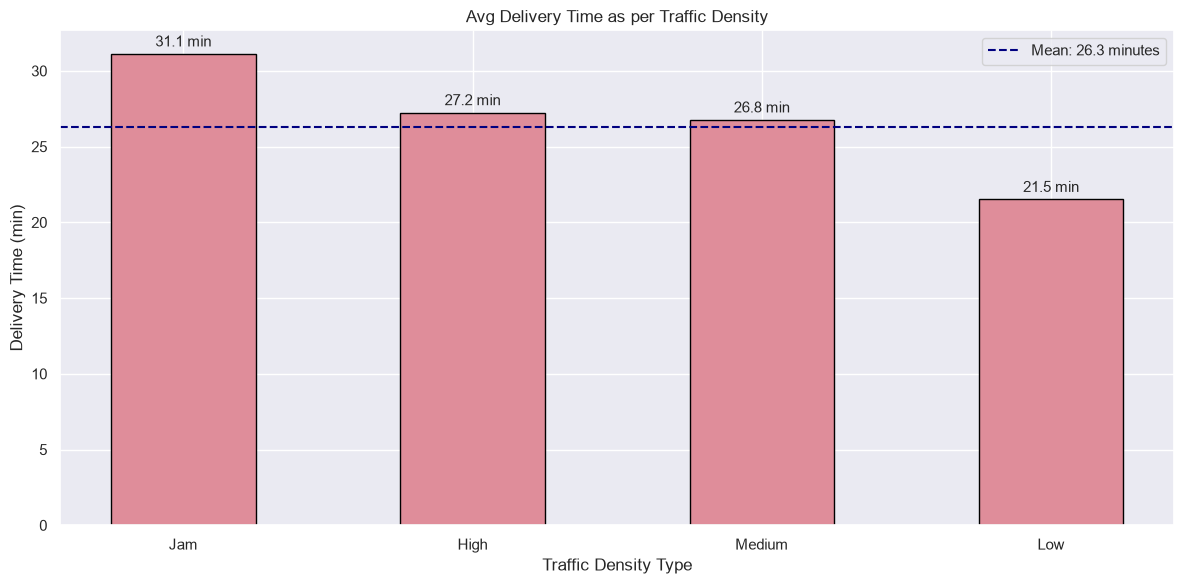

Avg Delivery Time as per Traffic Density
Road_traffic_density  Time_taken_min
                 Jam       31.111500
                High       27.235376
              Medium       26.754964
                 Low       21.508036


In [33]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(12,6))
bars = plt.bar(traffic_avg['Road_traffic_density'],
               traffic_avg['Time_taken_min'],
               color="#DF8D9A", edgecolor='black', width=0.5)

for bar, val in zip(bars, traffic_avg['Time_taken_min']):
    plt.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{val:.1f} min", ha='center', fontsize=11)

plt.axhline(df['Time_taken_min'].mean(),
            color='navy', linestyle='--',
            label=f"Mean: {df['Time_taken_min'].mean():.1f} minutes")

plt.legend()
plt.title('Avg Delivery Time as per Traffic Density')
plt.xlabel('Traffic Density Type')
plt.ylabel('Delivery Time (min)')
plt.tight_layout()
plt.savefig('../visuals/04_traffic_vs_delivery_time.png', dpi=150, bbox_inches='tight')
plt.show()

print('Avg Delivery Time as per Traffic Density')
print(traffic_avg.to_string(index=False))

In [34]:
# ── Step 5: Bivariate Analysis — City Type vs Delivery Time ──

city_avg = df.groupby('City')['Time_taken_min'].mean().sort_values(ascending=False).reset_index()
city_avg

,City,Time_taken_min
0,Metropolitan,27.312041
1,Urban,22.986052


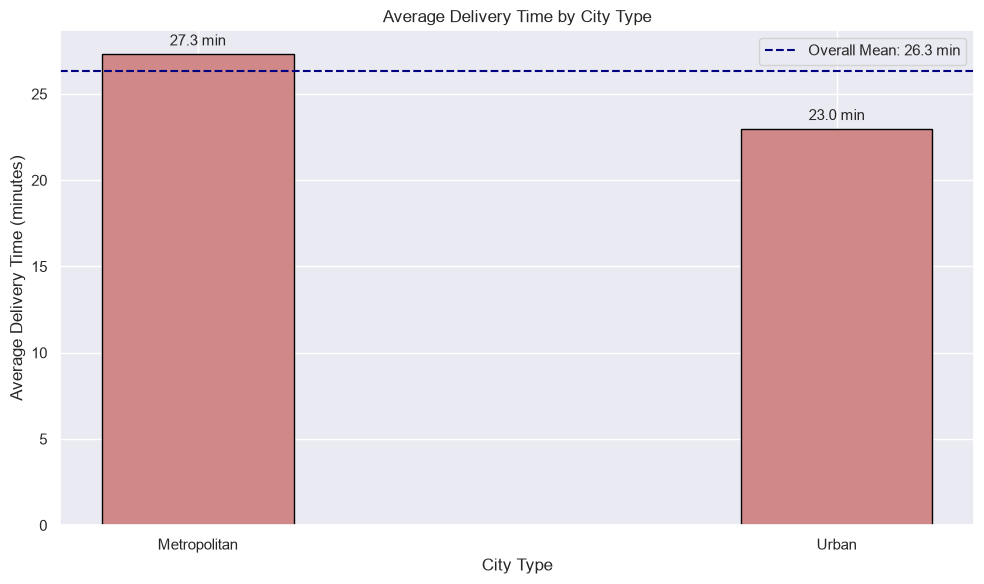

Avg Delivery Time City Type wise:
        City  Time_taken_min
Metropolitan       27.312041
       Urban       22.986052


In [35]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(10,6))

bars = plt.bar(city_avg['City'],
               city_avg['Time_taken_min'],
               color="#D18888", edgecolor='black', width=0.3)

for bar, val in zip(bars, city_avg['Time_taken_min']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f} min', ha='center', fontsize=11)
    
plt.axhline(df['Time_taken_min'].mean(), color='navy',
            linestyle='--', label=f"Overall Mean: {df['Time_taken_min'].mean():.1f} min")
plt.title('Average Delivery Time by City Type')
plt.xlabel('City Type')
plt.ylabel('Average Delivery Time (minutes)')
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/05_city_vs_delivery_time.png', dpi=150, bbox_inches='tight')
plt.show()

print('Avg Delivery Time City Type wise:')
print(city_avg.to_string(index=False))

In [36]:
# ── Step 6: Bivariate Analysis — Vehicle Type vs Delivery Time ──

vehicle_avg = df.groupby('Type_of_vehicle')['Time_taken_min'].mean().sort_values(ascending=False).reset_index()
vehicle_avg

,Type_of_vehicle,Time_taken_min
0,motorcycle,27.584776
1,scooter,24.582020
2,electric_scooter,24.510000


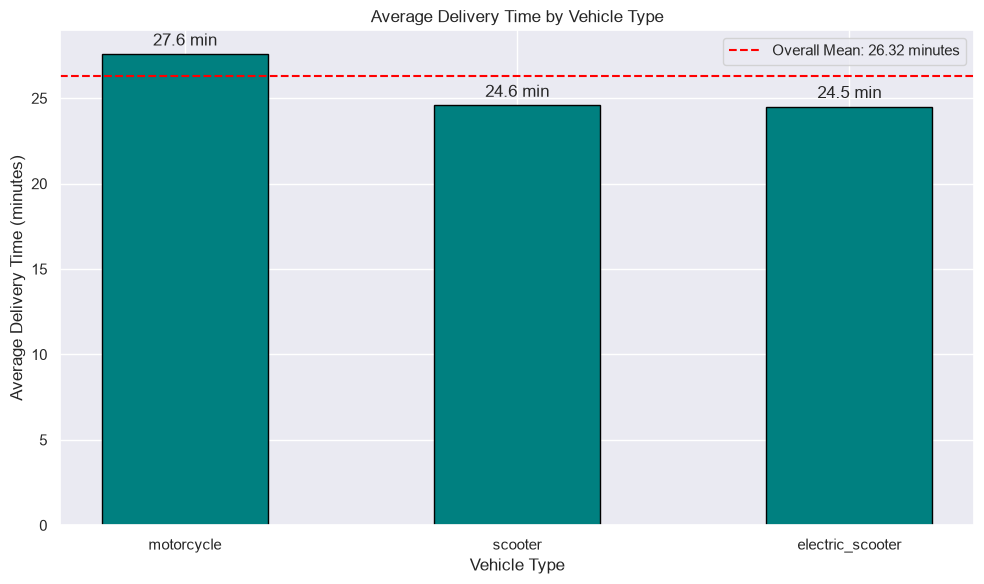

Average delivery time by vehicle type:
 Type_of_vehicle  Time_taken_min
      motorcycle       27.584776
         scooter       24.582020
electric_scooter       24.510000


In [37]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(10,6))

bars = plt.bar(vehicle_avg['Type_of_vehicle'],
               vehicle_avg['Time_taken_min'],
               color='teal', edgecolor='black', width=0.5)

for bar, val in zip(bars, vehicle_avg['Time_taken_min']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f} min', ha='center', fontsize=12)
    
plt.axhline(df['Time_taken_min'].mean(), color='red',
            linestyle='--',
            label = f"Overall Mean: {df['Time_taken_min'].mean():.2f} minutes")

plt.title('Average Delivery Time by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Delivery Time (minutes)')
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/06_vehicle_vs_delivery_time.png', dpi=150, bbox_inches='tight')
plt.show()
    
print("Average delivery time by vehicle type:")
print(vehicle_avg.to_string(index=False))


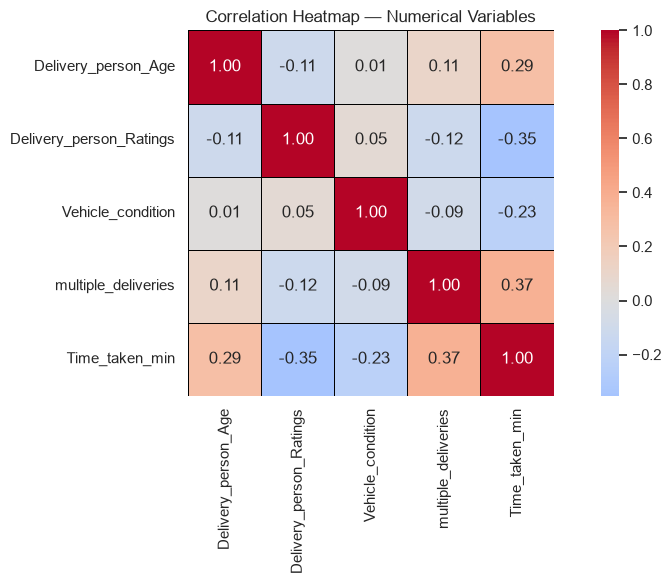

Correlation with Time_taken_min:
Time_taken_min             1.000000
multiple_deliveries        0.372792
Delivery_person_Age        0.291292
Vehicle_condition         -0.229760
Delivery_person_Ratings   -0.352931
Name: Time_taken_min, dtype: float64


In [38]:
# ── Step 7: Correlation Heatmap — Numerical Variables ──

plt.figure(figsize=(10,6))

numerical_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 
                  'Vehicle_condition', 'multiple_deliveries', 
                  'Time_taken_min']

corelation_matrix = df[numerical_cols].corr()

sns.heatmap(corelation_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            linecolor='black')

plt.title('Correlation Heatmap — Numerical Variables')
plt.tight_layout()
plt.savefig('../visuals/07_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


print("Correlation with Time_taken_min:")
print(corelation_matrix['Time_taken_min'].sort_values(ascending=False))

## Phase 3 — EDA Summary

### Key findings from Exploratory Data Analysis:

| Variable | Finding |
|---|---|
| Delivery Time | Average 26.3 min, right-skewed, std dev 9.3 min |
| Weather | Cloudy and Fog add ~32% more time vs Sunny |
| Traffic | Jam conditions add 44% more time vs Low traffic |
| City | Metropolitan takes 18.7% longer than Urban |
| Vehicle | Motorcycle takes 12% longer than scooter |
| Multiple Deliveries | Strongest positive correlation with delay (0.37) |
| Ratings | Higher rated partners deliver faster (-0.35) |
| Vehicle Condition | Better condition means faster delivery (-0.23) |

## Phase 4 — Core Business Analysis

### What is Core Business Analysis?
This phase moves beyond exploration into answering our 5 locked 
business questions with precision. Every analysis here is directed 
at a specific operational question that the Zomato ops team would 
actually ask.

Unlike EDA where we explored freely, here every chart and 
calculation has a specific business question it is answering.

### The 5 Business Questions:
1. Which city type has the worst delivery performance?
2. Does delivery person age or ratings affect delivery time?
3. Do weather and road traffic significantly increase delivery time?
4. Which order types and vehicle types are associated with most delays?
5. What is the single biggest lever the ops team should pull?